# Final Project: Demographic Predictors of Wine Spending

**Group Members:** Maksim Strelkov, Darshit Sapkota , Hrishil Patel, Shayan Dhillon


**Date**: 02/04/2026

---

## Research Question

**Which customer demographics and behaviors best predict wine spending?**

This project analyzes a customer personality dataset from kaggle to determine which demographic and behavioral factors best predict wine spending. Using exploratory data analysis, clustering, and predictive modelling, we investigate the following:

Investigate:

1. How much children & teens in home affects time since purchase & amount spent

2. Are people of a certain marital status more likely to spend more and often?
    
3. What income group is more likely to spend on wine?

4. Can customers be segmented into distinct groups based on demographics and purchasing behavior using clustering techniques?

5. Can machine learning models (regression and classification) accurately predict wine spending based on customer demographics and behaviors?

**Data Source:** [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

---

# 0. GitHub Repository link

The IPYNB was hosted publically on GitHub with a commit history of everyones contributions here: [Repository](https://github.com/ShayanDhillon/Data200-Final-Customers)



---

# 1. Setup & Data Loading

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, f1_score


columns_to_keep = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines']

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df[columns_to_keep]
print("Data shape:", df.shape)


Data shape: (2240, 10)


The dataset has ten columns across thousands of varying customers

Customers

    - ID:             Customer's unique identifier
    - Year_Birth:     Customer's birth year
    - Education:      Customer's education level
    - Marital_Status: Customer's marital status
    - Income:         Customer's yearly household income
    - Kidhome:        Number of children in customer's household
    - Teenhome:       Number of teenagers in customer's household
    - Dt_Customer:    Date of customer's enrollment with the company
    - Recency:        Number of days since customer's last purchase
    - Complain:       1 if the customer complained in the last 2 years, 0 otherwise

Target

    - MntWines:       Amount spent on wine in last 2 years

---

# 2. Data Cleaning

In [98]:
# normal data cleaning and formatting stuff
# finding missing values, duplicates, outliers, etc. and fixing them

# missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0], end="\n\n")

# duplicates
print("Duplicate rows:", df.duplicated().sum(), end="\n\n")

#remove missing values
df = df.dropna()
print("Data shape after dropping missing values:", df.shape, end="\n\n")

Missing values:
Income    24
dtype: int64

Duplicate rows: 0

Data shape after dropping missing values: (2216, 10)



In [99]:
# make objects into categories

print("Non standard data types:")
print(df.select_dtypes(include=['object']).dtypes)

# convert Marital_Status to category
df['Marital_Status'] = df['Marital_Status'].astype('category')

#convert education to ordinal category
edu_order = ['Basic', 'Graduation', '2n Cycle', 'Master', 'PhD']
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

# convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

df.head(5)

Non standard data types:
Education         object
Marital_Status    object
Dt_Customer       object
dtype: object


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173


In [100]:
# clean up some categories, what do they really mean?


# make new marital status, changes to single or partnered
def simplify_marital_status(status):
    if status in ['Married', 'Together']:
        return 'Partnered'
    elif status in ['Single', 'Divorced', 'Widow', 'Alone']:
        return 'Single'
    else:
        return 'Other'

df['Marital_Simplified'] = df['Marital_Status'].apply(simplify_marital_status)
df['Marital_Simplified'] = df['Marital_Simplified'].astype('category')
#remove all "others"
df = df[df['Marital_Simplified'] != 'Other'] #removes "absurd" and "yolo" categories


After data cleaning, we are left with the data shape: (2212, 11), and the dataset is now ready for further feature engineering and exploration/analysis!

We made sure all columns are the correct data types (with proper ordering for ordinal variables).

---

# 3. Feature Engineering & Exploration

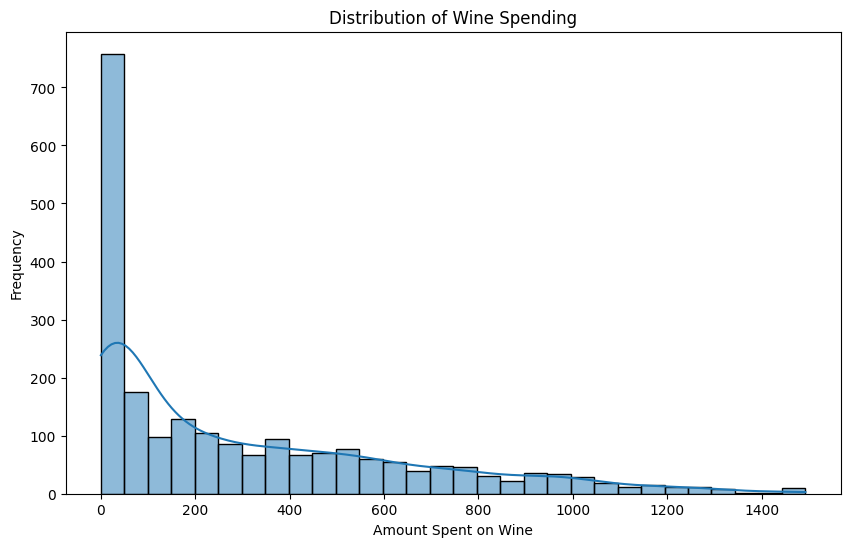

In [101]:
# distribution of wine spending to start off
plt.figure(figsize=(10, 6))
sns.histplot(df['MntWines'], bins=30, kde=True)
plt.title('Distribution of Wine Spending')
plt.xlabel('Amount Spent on Wine')
plt.ylabel('Frequency')
plt.show()


**Interpretation:**

The distribution of wine spending is very right-skewed, most customers spend low amounts on wine, only very few customers are high spenders. As shown by the long tail which extends to large spending amounts, there exists a premium segment of customers that drives a large portion of revenue from wine sales!

Finding commonalities among high spenders will be important for understanding the factors that drive increased spending on wine.


In [102]:
# family types: "No Kids", "Young Kids", "Teenagers", "Both"
# return the family type based on the age of the child in the home
def family_types(type):
    if type["Kidhome"] == 0 and type["Teenhome"] == 0:
        return "No Kids"
    elif type["Kidhome"] > 0 and type["Teenhome"] == 0:
        return "Kid Only"
    elif type["Kidhome"] == 0 and type["Teenhome"] > 0:
        return "Teen Only"
    else:
        return "Both"

# apply the function above as a new column then make sure its a categorical column
df["Family_Type"] = df.apply(family_types, axis=1)
df["Family_Type"] = df["Family_Type"].astype("category")

# Create a new column which separates the incomes into 3 ~equal distinct groups using qcut
df["Income_Group"] = pd.qcut(df["Income"], q=3, labels=['Low', "Middle", "High"])


3.1 How much children & teens in home affects amount spent
    (children, teen and both, make new feature on family type)

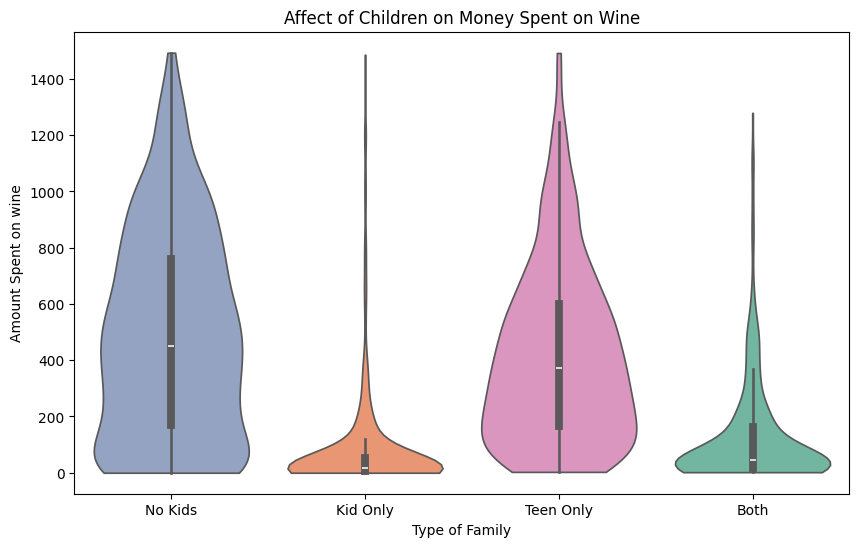

In [103]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Family_Type", y= "MntWines", data=df, order=["No Kids", "Kid Only", "Teen Only", "Both"], density_norm="width",cut=0, palette="Set2", hue="Family_Type")
plt.title("Affect of Children on Money Spent on Wine")
plt.xlabel("Type of Family")
plt.ylabel("Amount Spent on wine")
plt.show()

**Interpretation:**

From this data we can tell that there is a significant disparity between what seems to be 2 groups of data. The two sets being "having a young child" and "not having a young child". Customers with young children according to the data are much less likely to spend much on wine as opposed to customers without young children. Those without young children spend more on average and on outliers when compared to those with young children.

3.2 Are people of a certain marital status more likely to spend more and often?

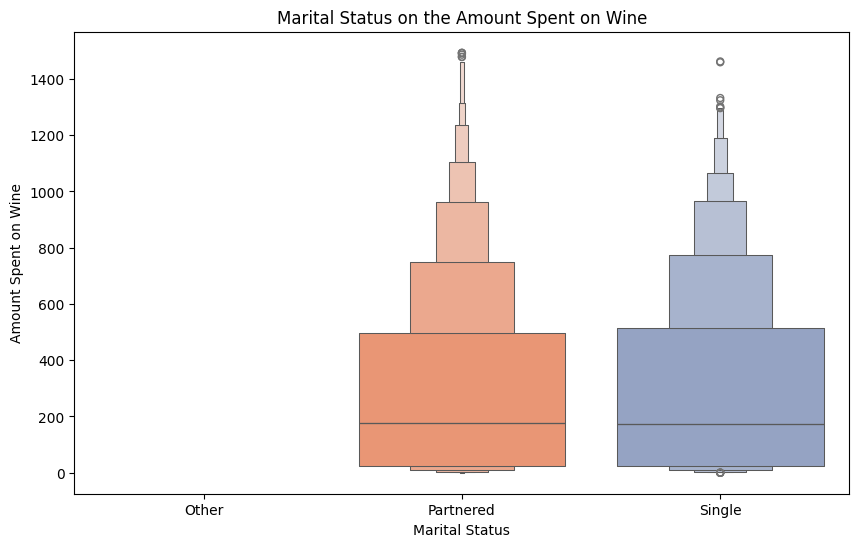

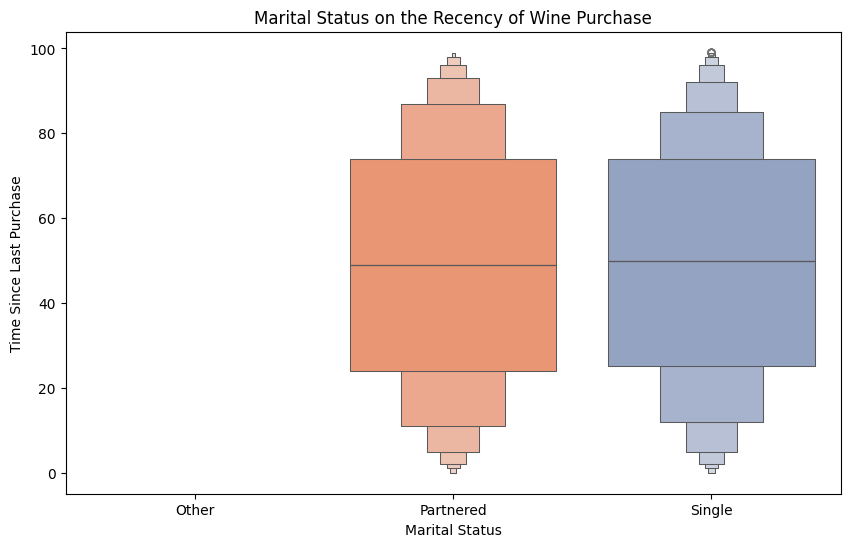

In [104]:

plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x="Marital_Simplified", y="MntWines", hue="Marital_Simplified", palette="Set2", dodge=False)
plt.title("Marital Status on the Amount Spent on Wine")
plt.ylabel("Amount Spent on Wine")
plt.xlabel("Marital Status")
plt.show()

plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x="Marital_Simplified", y="Recency", hue="Marital_Simplified", palette="Set2", dodge=False)
plt.title("Marital Status on the Recency of Wine Purchase")
plt.xlabel("Marital Status")
plt.ylabel("Time Since Last Purchase")
plt.show()

**Interpretation:**

There was not a very large sample of 'Other' therefore it is not visible on the plot.

The plotting of this dataset shows no clean indication that the maritial status of the customer affects the Amount Spent nor the Days since purchase. Partnered individuals are very minimally more inclined to spend more on wine but this different is small enough to be a sampling limitation. The Recency of purchase has no visible differences in the different categories.


3.3 What income group is more likely to spend on wine?

Income_Group
Low       738
Middle    737
High      737
Name: count, dtype: int64

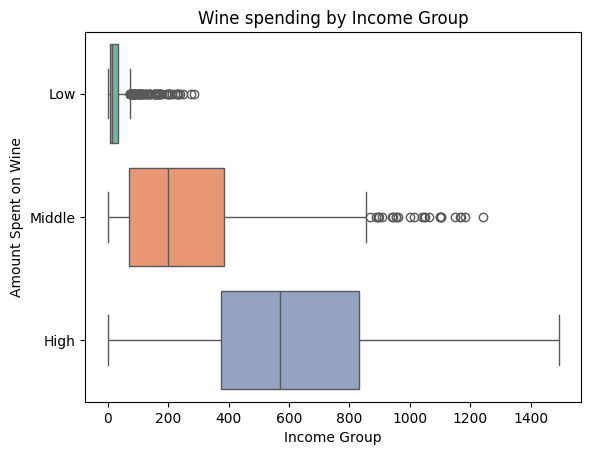

In [105]:
sns.boxplot(data=df, y="Income_Group", x="MntWines", order=["Low", "Middle", "High"], palette="Set2", hue="Income_Group")

plt.title("Wine spending by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Amount Spent on Wine")

df["Income_Group"].value_counts()


**Interpretation:**

The plot expresses a positive correlation between income group and the amount spent on wines, those in the low income group are spending very little on wine other than outliers which spend in the interquartile range of the middle income group. Through this data and the value count extracted of each category, we can understand that middle and high income groups are the higher spenders when compared to low income while also having around the same number of unique IDs.  


---

# 4. Modelling

## USE Regularization techniques, with appropriate interpretations (especially regarding the bias-variance tradeoff)

Setup

In [106]:
#  cross validation, test train set etc
model_df = df.copy()

model_df["Age"] = model_df["Dt_Customer"].dt.year.max() - model_df["Year_Birth"]
model_df["Customer_Days"] = (model_df["Dt_Customer"].max() - model_df["Dt_Customer"]).dt.days
model_df["High_Spender"] = (model_df["MntWines"] >= model_df["MntWines"].median()).astype(int)

numeric_features = ["Age", "Income", "Kidhome", "Teenhome", "Recency", "Customer_Days"]
categorical_features = ["Education", "Marital_Simplified", "Family_Type", "Income_Group"]

feature_columns = numeric_features + categorical_features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

X_base = model_df[feature_columns]
y_reg = model_df["MntWines"]
y_cls = model_df["High_Spender"]

X_train_base, X_test_base, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X_base,
    y_reg,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Training set shape:", X_train_base.shape)
print("Test set shape:", X_test_base.shape)
print("Median wine spending for classification:", model_df["MntWines"].median())

Training set shape: (1769, 10)
Test set shape: (443, 10)
Median wine spending for classification: 173.5


4.1 Clustering

In [107]:
#CLUSTERING FIRST, make clusters as a feature and use in model
cluster_features = ["Income", "MntWines", "Recency", "Kidhome", "Teenhome"]
cluster_scaled = StandardScaler().fit_transform(model_df[cluster_features])

k_values = list(range(2, 7))
inertias = []

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=1, max_iter=50, algorithm="lloyd")
    kmeans_model.fit(cluster_scaled)
    inertias.append(kmeans_model.inertia_)

best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=1, max_iter=50, algorithm="lloyd")
model_df["Cluster"] = kmeans.fit_predict(cluster_scaled).astype(str)

cluster_summary = model_df.groupby("Cluster")[cluster_features].mean().round(1)
cluster_summary["Count"] = model_df["Cluster"].value_counts().sort_index().values
display(cluster_summary)

# add cluster as a new categorical feature
categorical_features_model = categorical_features + ["Cluster"]
feature_columns_model = numeric_features + categorical_features_model

preprocessor_model = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_model)
    ]
)

X = model_df[feature_columns_model]

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

,Income,MntWines,Recency,Kidhome,Teenhome,Count
Cluster,,,,,,
0,58585.5,416.8,49.1,0.1,1.1,680
1,34276.4,63.1,23.7,0.9,0.3,506
2,78153.1,636.1,49.9,0.0,0.0,516
3,35351.6,61.1,73.3,0.9,0.4,510


**Interpretation:**  
The clustering step separates customers into useful behavioural groups before prediction. The clusters mainly split between high-income / high-wine customers and lower-income / low-wine customers while recency and household makeup add a second layer of separation.

4.2 Model Building

In [108]:
#Regression and Classification
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
}

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
}

regression_results = []
classification_results = []

for name, model in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_model),
        ("model", model)
    ])

    cv_r2 = cross_val_score(pipeline, X_train, y_reg_train, cv=3, scoring="r2", n_jobs=1).mean()
    cv_rmse = -cross_val_score(pipeline, X_train, y_reg_train, cv=3, scoring="neg_root_mean_squared_error", n_jobs=1).mean()

    pipeline.fit(X_train, y_reg_train)
    predictions = pipeline.predict(X_test)

    test_r2 = r2_score(y_reg_test, predictions)
    test_rmse = np.sqrt(mean_squared_error(y_reg_test, predictions))

    regression_results.append({
        "Model": name,
        "CV_R2": round(cv_r2, 3),
        "CV_RMSE": round(cv_rmse, 3),
        "Test_R2": round(test_r2, 3),
        "Test_RMSE": round(test_rmse, 3)
    })

for name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_model),
        ("model", model)
    ])

    cv_accuracy = cross_val_score(pipeline, X_train, y_cls_train, cv=3, scoring="accuracy", n_jobs=1).mean()
    cv_f1 = cross_val_score(pipeline, X_train, y_cls_train, cv=3, scoring="f1", n_jobs=1).mean()

    pipeline.fit(X_train, y_cls_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(y_cls_test, predictions)
    test_f1 = f1_score(y_cls_test, predictions)
    test_auc = roc_auc_score(y_cls_test, probabilities)

    classification_results.append({
        "Model": name,
        "CV_Accuracy": round(cv_accuracy, 3),
        "CV_F1": round(cv_f1, 3),
        "Test_Accuracy": round(test_accuracy, 3),
        "Test_F1": round(test_f1, 3),
        "Test_AUC": round(test_auc, 3)
    })

regression_results_df = pd.DataFrame(regression_results)
classification_results_df = pd.DataFrame(classification_results)

display(regression_results_df)
display(classification_results_df)


,Model,CV_R2,CV_RMSE,Test_R2,Test_RMSE
0,Linear Regression,0.575,216.588,0.606,223.339
1,Decision Tree Regressor,0.566,218.451,0.617,220.182


,Model,CV_Accuracy,CV_F1,Test_Accuracy,Test_F1,Test_AUC
0,Logistic Regression,0.877,0.880,0.894,0.898,0.958
1,Decision Tree Classifier,0.868,0.868,0.876,0.878,0.952


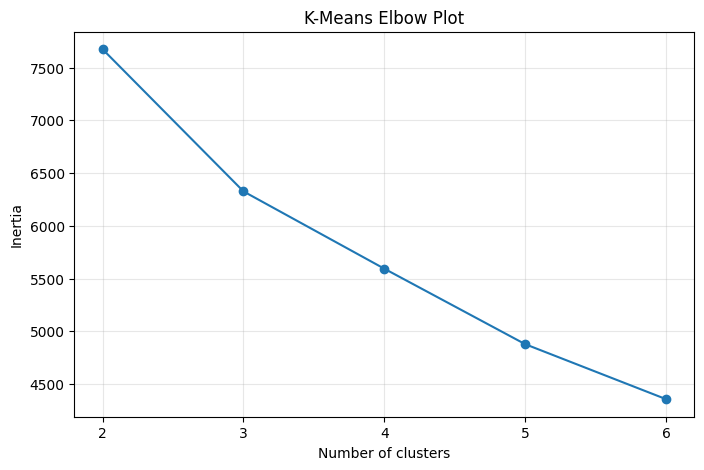

In [109]:
# convergence plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("K-Means Elbow Plot")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

**Interpretation:**  
The elbow plot starts to flatten around k = 4, so using four clusters is about the sweet spot. Anything below that is too coarse and blends clearly different customer groups together, while adding more clusters gives worse results and mostly overcomplicates the segmentation.

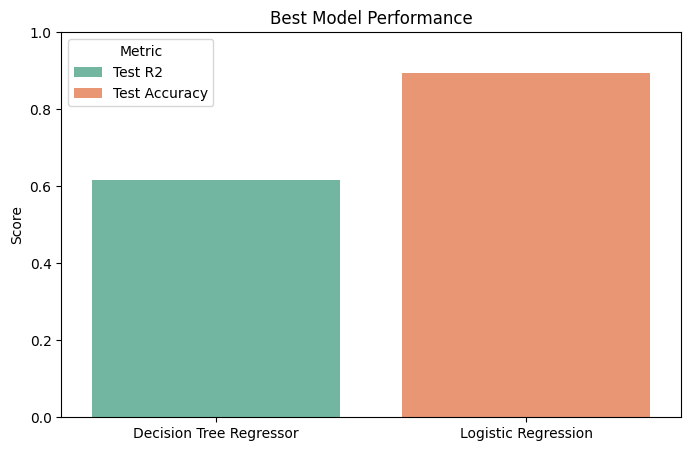

Best regression model:


,Model,CV_R2,CV_RMSE,Test_R2,Test_RMSE
1,Decision Tree Regressor,0.566,218.451,0.617,220.182


Best classification model:


,Model,CV_Accuracy,CV_F1,Test_Accuracy,Test_F1,Test_AUC
0,Logistic Regression,0.877,0.88,0.894,0.898,0.958


In [110]:
# final results plot
best_regression = regression_results_df.loc[regression_results_df["Test_R2"].idxmax()]
best_classification = classification_results_df.loc[classification_results_df["Test_Accuracy"].idxmax()]

final_plot_df = pd.DataFrame({
    "Model": [best_regression["Model"], best_classification["Model"]],
    "Score": [best_regression["Test_R2"], best_classification["Test_Accuracy"]],
    "Metric": ["Test R2", "Test Accuracy"]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=final_plot_df, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Best Model Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.show()

print("Best regression model:")
display(best_regression.to_frame().T)

print("Best classification model:")
display(best_classification.to_frame().T)

**Interpretation:**  
In the Regression the Decision Tree Regressor performs slightly better on the test set than Linear Regression, which suggests wine spending is not purely linear and benefits from simple non-linear splits. 
In the Classification the Logistic Regression gives the strongest accuracy and AUC, meaning it is very effective at separating above median and below median spenders. The weak point in the whole section is that regression error is still fairly large.

---


# 5. Conclusion


This research aimed to identify the customer demographics and behaviors that were most predictive of how much money would be spent on wine. Overall, our analysis identified some of the primary relationships among various different demographic variables, behavioural indicators, and model outputs.

The single strongest and most consistent predictor of how much money would be spent on wine was income. Middle-income and upper-income customers spent significantly more on wine than low-income customers did. This was illustrated clearly in both the distribution of wine spend and the boxplot analysis, and is consistent with what is expected, as individuals who have more disposable income can afford to spend more on things other than necessities, such as wine.

Another factor to consider when determining the relationships between how much money is spent on wine and certain demographics is household composition. Overall, customers without children spent more on wine than customers with children, and more particularly, customers with young children spent the least amount of money on wine. This indicates that financial or time-related constraints on lifestyle choices may limit discretionary spending. One interesting finding was that customers with teenage children spent more than customers with younger children, which may relate to the differing financial flexibility of the households.

In contrast to a strong correlation between marital status and wine expenditure, the difference in purchasing patterns of single and married customers is minimal.
This indicates that marital status by itself is not a major influence on wine purchase behaviour in this dataset

Behavioural analysis also revealed that the distribution of wine spending was highly skewed to the right; most customers spent very little on wine, while only a handful of customers contributed a significant portion of the total revenue generated. From this perspective, the need to identify, develop and target high-value customers is critical to generating total wine sales.

Clustering analysis confirmed the results of the behavioural analysis, as the analysis produced customer clusters that were distinct groups based on both spending and income, with some differences by recency and household composition amongst the clusters. Therefore, customer segmentation is an effective way to understand and categorize purchasing behaviour prior to the use of predictive models.

During the modelling process, both classification and regression methods were used to predict spending on wine. For the regression model, the Decision Tree Regressor had a better predictive performance than Linear Regression, indicating that there is a nonlinear relationship between certain features and how much wine customers spend. When the data was analysed for classification through Logistic Regression, the model produced very good accuracy as well as AUC scores which show that it did a good job of distinguishing between customers that spend above average compared to below average on wine. However, there was still a relatively high regression error value in the model indicating that there are probably other undetermined factors affecting wine spending that cannot be identified within the dataset.

Overall, the key factors found to have the greatest predictive power in regard to predicting the amount that customers spend on wine are income, household composition and customer segmentation, while marital status was found to have a minimal effect in comparison. The combination of exploratory analysis, clustering and predictive modelling has created an overall picture of customer behaviour.

One limitation to this analysis is that only a limited number of demographic and behavioural variables are used. Future studies should include more specific feature data such as purchase history, product preference or exposure to promotions to enhance predictability based on these features within the data set. Notwithstanding, this research has provided a wealth of information from which to better understand customer spending behaviour and develop marketing strategies to target customers based upon their spending behaviour.